# Email Spam Classification using Linear SVM

**Objective:** Classify emails as **Spam (1)** or **Not Spam (0)** using a Linear Support Vector Machine.

**Dataset:** Email Spam Classification Dataset from Kaggle.  
The dataset contains 5,172 emails, 3,002 columns, 3,000 word-frequency features, an email-name/ID column, and the final prediction label. citeturn0search0

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

Download `emails.csv` from Kaggle and keep it in the same folder as this notebook.

In [2]:
df = pd.read_csv("emails.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


## 3. Dataset Information

In [3]:
print("Columns:", df.shape[1])
print("Rows:", df.shape[0])
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass distribution:")
print(df.iloc[:, -1].value_counts())

Columns: 3002
Rows: 5172

Missing values: 0

Class distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64


## 4. Separate Features and Target

The first column is the email name/ID and is not useful for classification.  
The last column is the target: **1 = Spam, 0 = Not Spam**. The remaining columns contain word-frequency counts. citeturn0search0

In [4]:
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5172, 3000)
Target shape: (5172,)


## 5. Train-Test Split

We use 80% of the data for training and 20% for testing. `stratify=y` keeps the spam/non-spam proportion similar in both sets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4137
Testing samples: 1035


## 6. Build Linear SVM Model

`LinearSVC` implements a linear Support Vector Machine and is suitable for high-dimensional word-frequency features.

In [6]:
svm_model = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=5000
)

svm_model.fit(X_train, y_train)

print("Linear SVM model trained successfully.")

Linear SVM model trained successfully.


## 7. Make Predictions

In [7]:
y_pred = svm_model.predict(X_test)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 1 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0]


## 8. Accuracy

In [8]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9749
Accuracy: 97.49%


## 9. Confusion Matrix

Confusion Matrix:
[[721  14]
 [ 12 288]]


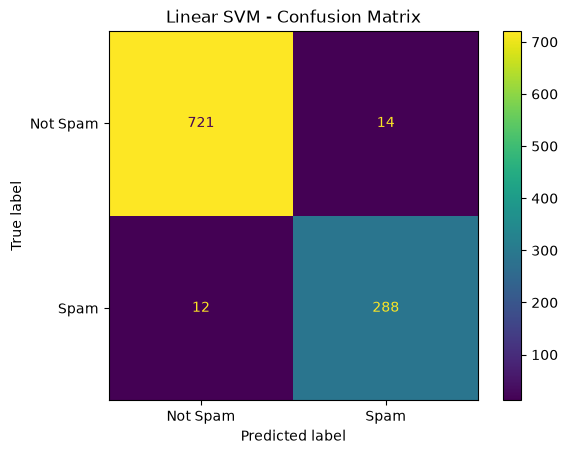

In [9]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Spam", "Spam"]
).plot()

plt.title("Linear SVM - Confusion Matrix")
plt.show()

## 10. Classification Report

In [10]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Spam", "Spam"]
))

              precision    recall  f1-score   support

    Not Spam       0.98      0.98      0.98       735
        Spam       0.95      0.96      0.96       300

    accuracy                           0.97      1035
   macro avg       0.97      0.97      0.97      1035
weighted avg       0.97      0.97      0.97      1035



## 11. Model Evaluation

The model is evaluated using:

- **Accuracy:** Overall percentage of correct predictions.
- **Precision:** How many emails predicted as spam are actually spam.
- **Recall:** How many actual spam emails are detected.
- **F1-score:** Balance between precision and recall.

For spam detection, recall and precision are especially important because both missed spam and incorrectly flagged legitimate emails matter.

## 12. Conclusion

A **Linear Support Vector Machine** was successfully trained on the email word-frequency features. The model predicts whether an email is **Spam** or **Not Spam** and is evaluated using accuracy, confusion matrix, precision, recall and F1-score.